# Taller 3: Introducción a la IA - Regresión Lineal y Árboles de Decisión

**Autor:** Yoichi Palacios Tanaka
**Curso:** Proyecto Integrador 2026-2 - Equipo 02
**Proyecto:** LanternGuard, monitoreo de biofouling en linternas de cultivo de concha de abanico

En este taller se ajusta un modelo de regresión lineal multivariable para predecir el
**consumo de energía** de un equipo a partir de cuatro variables de operación, y luego se
compara contra un árbol de decisión. El interés para el proyecto es directo: el nodo
sumergido de LanternGuard funciona con batería cargada por un panel solar en la boya, así
que saber qué variable domina el consumo decide cómo se programa el ciclo de trabajo.

## Importamos paquetes

In [1]:
import numpy as np              # Cálculos numéricos y manejo de arreglos/matrices.
import pandas as pd             # Organizar, limpiar y analizar datos en forma de tablas.
import matplotlib.pyplot as plt # Crear gráficos
import seaborn as sns           # Crear gráficos estadísticos más elaborados y visualmente agradables.
%matplotlib inline
# Hace que los gráficos de Matplotlib aparezcan dentro de la celda de Colab/Jupyter.

Definimos también dónde se guardan las figuras. Si el notebook se ejecuta dentro del
repositorio, las imágenes van a `Recursos/Imágenes/`; si se ejecuta en Colab, se guardan
junto al notebook.

In [2]:
import os

RUTA_IMG = os.path.join("..", "..", "..", "..", "Recursos", "Imágenes")
if not os.path.isdir(RUTA_IMG):
    RUTA_IMG = "."   # Colab u otra ubicación: guarda junto al notebook
print("Las figuras se guardarán en:", os.path.abspath(RUTA_IMG))

Las figuras se guardarán en: C:\Users\Usuario\Documents\Portfolio\proyecto integrado upch\repo\Recursos\Imágenes


## Importamos el conjunto de datos

El archivo `Data_PI_regresion.csv` es el mismo que se usó en clase. Tiene 5000 registros y
5 columnas: cuatro variables independientes (`Temperatura`, `Horas_Operacion`, `Carga`,
`Humedad`) y la variable que queremos predecir, `Consumo_Energia`.

In [3]:
df = pd.read_csv("Data_PI_regresion.csv")
df.head()   # vemos los 5 primeros datos del dataframe

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
0,29.8,7.4,76.4,87.0,28.97
1,22.9,4.3,88.8,74.9,21.85
2,21.9,10.4,87.7,65.7,37.43
3,27.4,7.8,55.7,79.0,26.32
4,30.2,6.9,42.3,62.9,26.08


## Consultar información básica sobre el conjunto de datos

### `info()` >> da información detallada

In [4]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      5000 non-null   float64
 1   Horas_Operacion  5000 non-null   float64
 2   Carga            5000 non-null   float64
 3   Humedad          5000 non-null   float64
 4   Consumo_Energia  5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


No hay valores nulos y las cinco columnas son `float64`, así que no hace falta limpiar
ni convertir tipos antes de modelar.

### `describe()` >> resumen de estadísticas

In [5]:
df.describe().round(1)

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
count,5000.0,5000.0,5000.0,5000.0,5000.0
mean,26.5,7.0,65.0,65.1,26.0
std,4.9,2.9,20.3,14.3,5.6
min,18.0,2.0,30.0,40.0,9.1
25%,22.1,4.4,47.3,52.7,21.8
50%,26.5,7.0,65.7,65.0,26.1
75%,30.7,9.4,82.5,77.5,30.3
max,35.0,12.0,100.0,90.0,42.6


### `columns` >> obtiene los nombres de las características

In [6]:
df.columns

Index(['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad',
       'Consumo_Energia'],
      dtype='str')

## Visualización básica

Graficamos cada variable independiente contra el consumo de energía. Lo que buscamos es
ver, a simple vista, cuál de las cuatro tiene una relación con forma de recta y cuál es
solo una nube sin dirección.

> En la clase esta lista se armó más adelante con `l = list(cdf.index)`, cuando ya existía
> el dataframe de coeficientes. Aquí se define antes con las mismas cuatro variables para
> poder ver los gráficos desde el inicio.

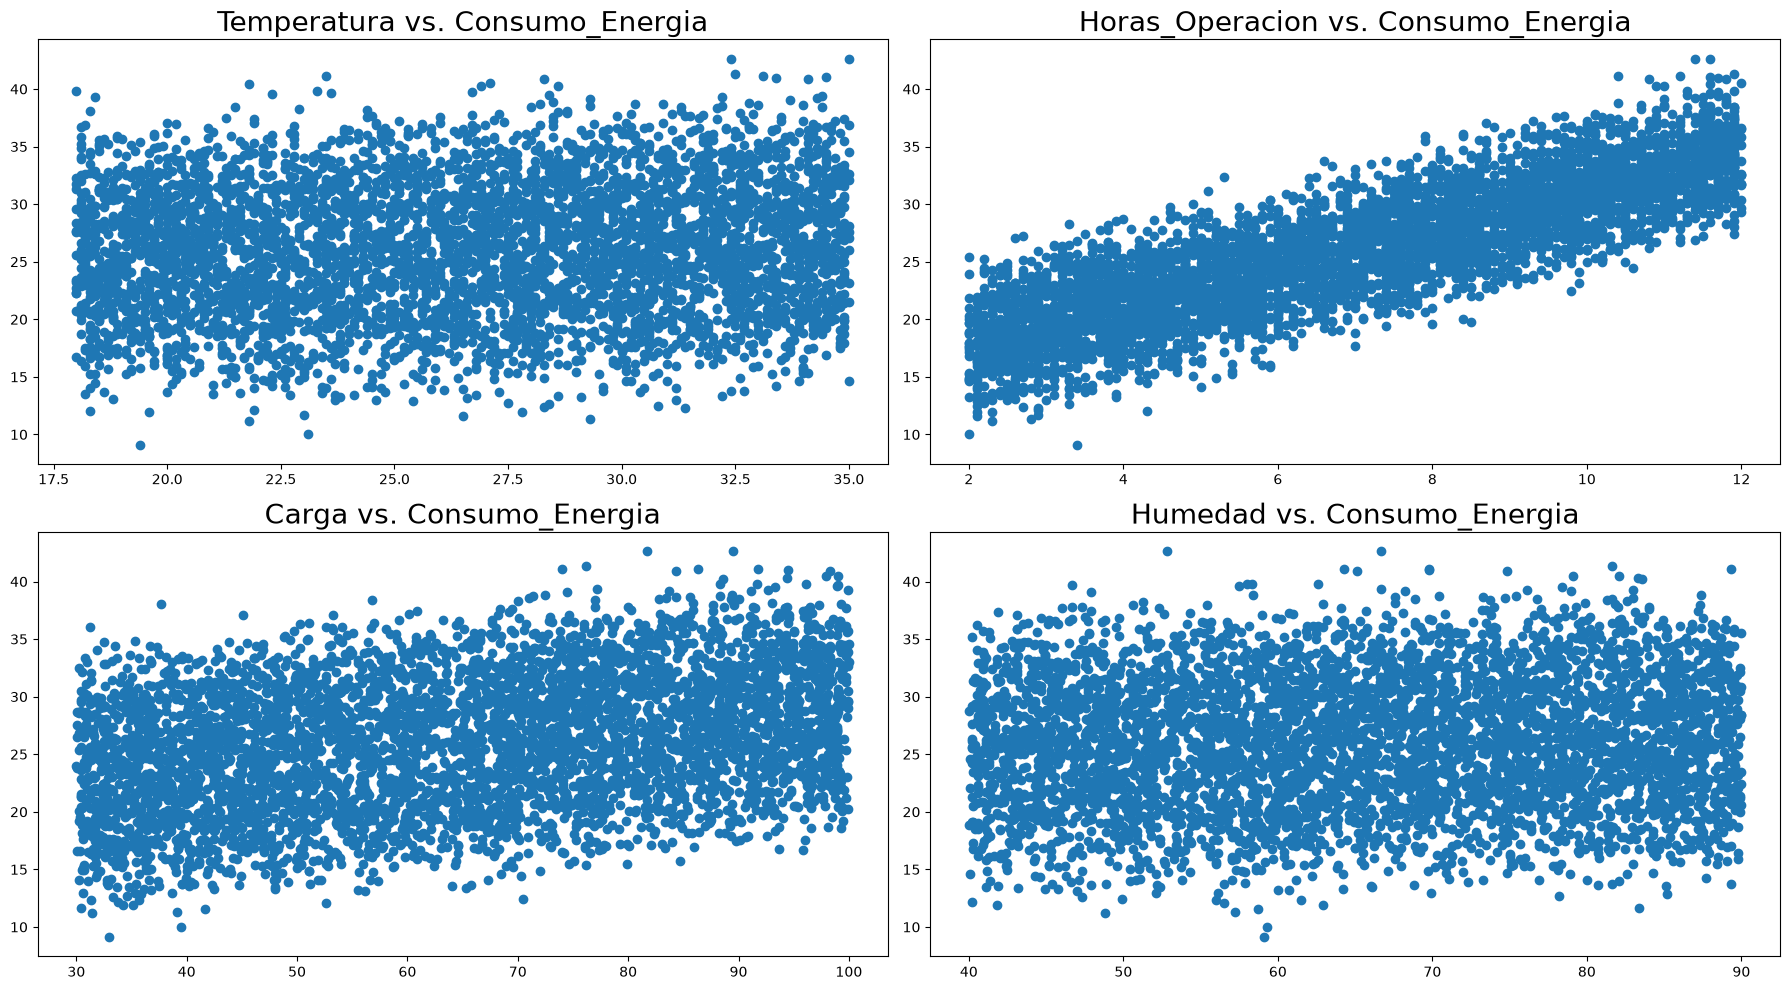

In [7]:
l = [col for col in df.columns if col != "Consumo_Energia"]

from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]], df["Consumo_Energia"])
ax0.set_title(l[0] + " vs. Consumo_Energia", fontdict={'fontsize': 20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df[l[1]], df["Consumo_Energia"])
ax1.set_title(l[1] + " vs. Consumo_Energia", fontdict={'fontsize': 20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df[l[2]], df["Consumo_Energia"])
ax2.set_title(l[2] + " vs. Consumo_Energia", fontdict={'fontsize': 20})

ax3 = plt.subplot(gs[3])
ax3.scatter(df[l[3]], df["Consumo_Energia"])
ax3.set_title(l[3] + " vs. Consumo_Energia", fontdict={'fontsize': 20})

plt.tight_layout()
plt.savefig(os.path.join(RUTA_IMG, "Taller3_Palacios_Dispersion.png"), dpi=120, bbox_inches="tight")
plt.show()

Solo `Horas_Operacion` dibuja una banda claramente inclinada. `Carga` insinúa una
pendiente suave, y `Temperatura` y `Humedad` son nubes sin dirección.

## Distribución del consumo de energía

'\nHistograma: ¿Cómo se distribuyen los datos por intervalos?\n'

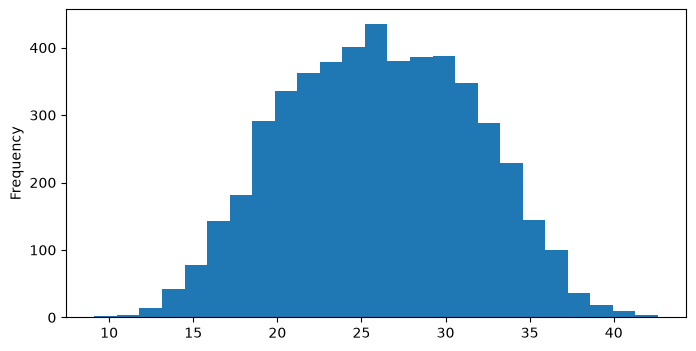

In [8]:
df['Consumo_Energia'].plot.hist(bins=25, figsize=(8, 4))
# histograma en 25 intervalos
'''
Histograma: ¿Cómo se distribuyen los datos por intervalos?
'''
# figsize(ancho, alto): tamaño de la figura

'\nDensidad: ¿Dónde están concentrados los datos?\n'

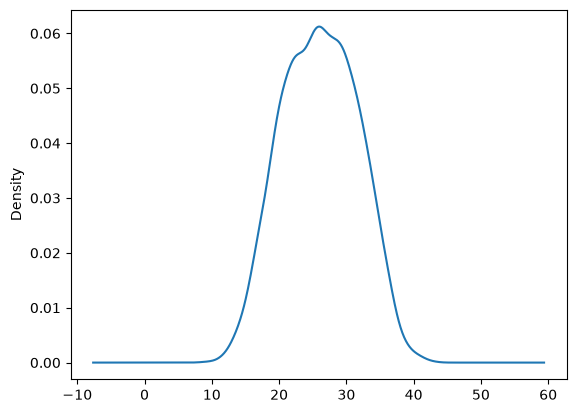

In [9]:
df['Consumo_Energia'].plot.density()
'''
Densidad: ¿Dónde están concentrados los datos?
'''

## Relaciones entre todas las variables

`pairplot` genera una matriz que compara todas las variables entre sí y, en la diagonal,
muestra la distribución de cada una.

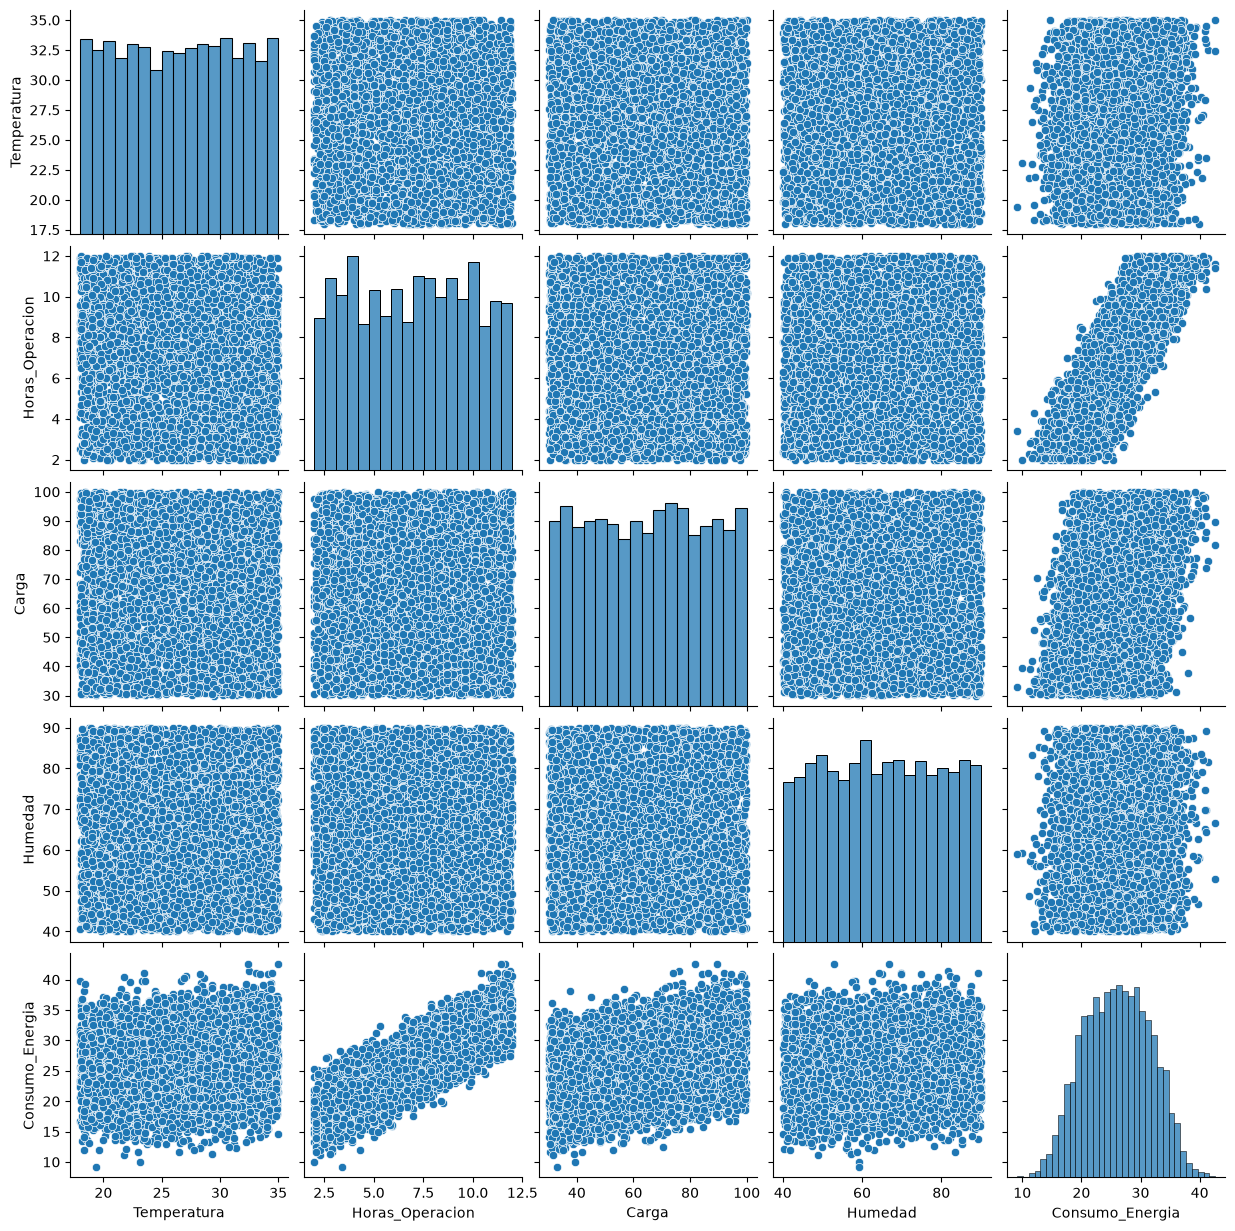

In [10]:
sns.pairplot(df)

## Matriz de correlación y heatmap

El coeficiente de correlación resume en un número, entre -1 y +1, qué tan fuerte es la
relación lineal entre dos variables.

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
# Selecciona solo las columnas con valores numéricos

numeric_df.corr().round(4)
# Cálculo de la correlación

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
Temperatura,1.0000,-0.0260,0.0102,0.0166,0.0978
Horas_Operacion,-0.0260,1.0000,-0.0099,0.0060,0.8434
Carga,0.0102,-0.0099,1.0000,0.0060,0.3366
Humedad,0.0166,0.0060,0.0060,1.0000,0.0627
Consumo_Energia,0.0978,0.8434,0.3366,0.0627,1.0000


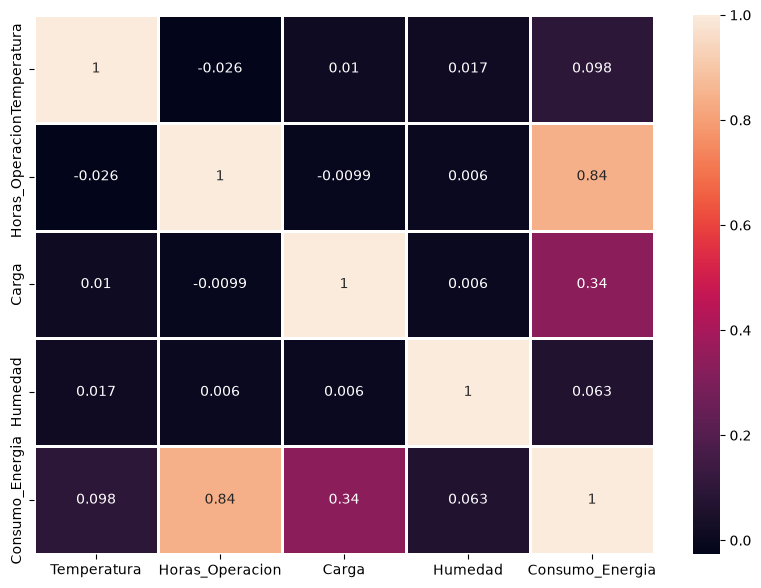

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2)
# Mapa de calor de correlaciones
plt.savefig(os.path.join(RUTA_IMG, "Taller3_Palacios_Heatmap.png"), dpi=120, bbox_inches="tight")
plt.show()

Interpretación de cada coeficiente contra `Consumo_Energia`:

- **Horas de operación → 0.84.** Está bastante cerca de +1, por lo que existe una fuerte
  relación lineal positiva. A medida que aumentan las horas de operación, tiende a aumentar
  el consumo energético.
- **Carga → 0.34.** Es una relación positiva moderada/baja. Cuando aumenta la carga, el
  consumo tiende a aumentar.
- **Temperatura → 0.098.** Es una relación muy débil.
- **Humedad → 0.063.** También es una relación muy débil, prácticamente cercana a cero.

Un detalle importante para lo que viene: entre las variables independientes las
correlaciones son casi nulas (todas por debajo de 0.03 en valor absoluto). Es decir, no hay
multicolinealidad, y eso justifica el método simplificado de errores estándar que se usa
más abajo.

## Conjunto de características y variable objetivo

In [13]:
X = df[['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad']]
y = df['Consumo_Energia']

print("Variables independientes (X):", list(X.columns))
print("Variable dependiente  (y):", y.name)

Variables independientes (X): ['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad']
Variable dependiente  (y): Consumo_Energia


## Dividimos entrenamiento-prueba

Separamos los datos para entrenar con una parte y evaluar con otra que el modelo nunca vio.
Si evaluáramos con los mismos datos de entrenamiento, no sabríamos si el modelo aprendió o
solo memorizó.

In [14]:
from sklearn.model_selection import train_test_split
# divide datos en: entrenamiento y prueba

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)
# 70%: entrenamiento
# 30%: prueba
# random_state=123 >> Haz la división aleatoria, pero reproducible.

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (3500, 4)  X_test: (1500, 4)
y_train: (3500,)  y_test: (1500,)


## Ajuste y entrenamiento del modelo

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
# machine learning
# modelo: regresión lineal
# métricas: ¿qué tan buenas son las predicciones?

In [17]:
lm = LinearRegression()  # Creando un objeto de Regresión Lineal 'lm'

In [18]:
lm.fit(X_train, y_train)  # Ajustar y entrenar

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.14,1.67,0.1 ,0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Temperatura','Horas_Operacion','Carga','Humedad']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.741
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


- El modelo busca los coeficientes que mejor relacionan esas variables con el consumo.
- Por eso, después de ejecutar `fit()`, el modelo ya tiene "aprendidos" sus parámetros.

In [19]:
# Verificamos la intercepción
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: 2.7410674461174693


In [20]:
# Verificamos el modelo lineal
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [0.13713677 1.66877804 0.09634816 0.02679108]


In [21]:
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])
cdf

,Coefficients
Temperatura,0.137137
Horas_Operacion,1.668778
Carga,0.096348
Humedad,0.026791


Cada coeficiente indica cuánto cambia el consumo de energía cuando esa variable aumenta
en una unidad y las demás se mantienen fijas. El coeficiente de `Horas_Operacion` es el más
grande con diferencia: una hora más de operación pesa mucho más que un grado más de
temperatura.

## Predicción sobre el conjunto de prueba

In [22]:
predictions = lm.predict(X_test)
print("Tipo del objeto predicho :", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (1500,)


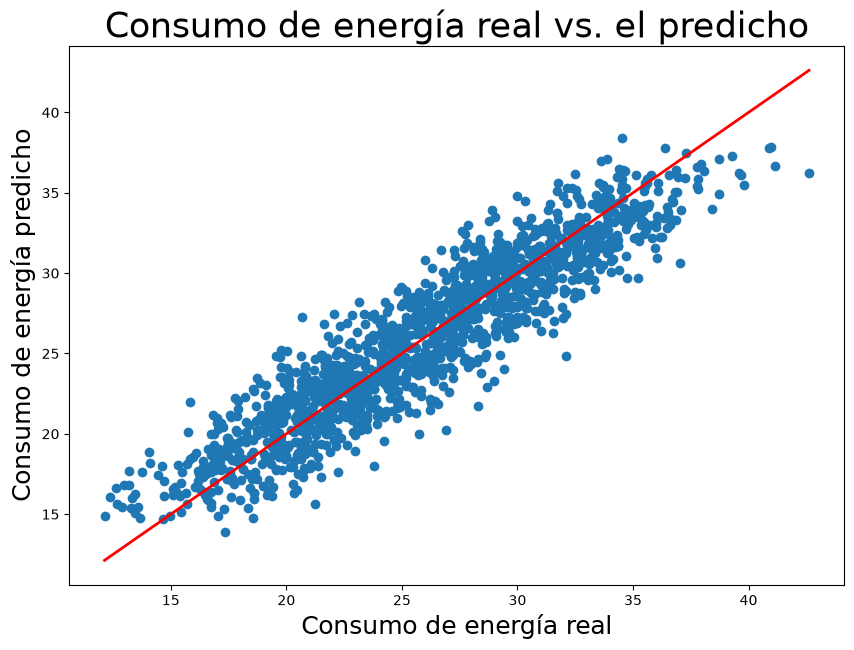

In [23]:
# Diagrama de dispersión
'''
Idea: Datos caen en una línea recta de 45°
'''
plt.figure(figsize=(10, 7))
plt.title("Consumo de energía real vs. el predicho", fontsize=25)
plt.xlabel("Consumo de energía real", fontsize=18)
plt.ylabel("Consumo de energía predicho", fontsize=18)
plt.scatter(x=y_test, y=predictions)

# Línea de 45° de referencia: si el modelo fuera perfecto, todos los puntos caerían sobre ella.
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
plt.plot(lims, lims, color="red", linewidth=2)

plt.savefig(os.path.join(RUTA_IMG, "Taller3_Palacios_Real_vs_Predicho.png"), dpi=120, bbox_inches="tight")
plt.show()

## Matrices de evaluación del modelo

Cuatro métricas para responder qué tan buenas son las predicciones:

- **MAE** (error absoluto medio): en promedio, cuántos kWh se equivoca el modelo. Está en
  las mismas unidades que la variable, así que es la más fácil de interpretar.
- **MSE** (error cuadrático medio): promedio de los errores al cuadrado. Al elevar al
  cuadrado, castiga más los errores grandes que los pequeños.
- **RMSE** (raíz del error cuadrático medio): la raíz del anterior, para volver a las
  unidades originales.
- **R²** (coeficiente de determinación): qué proporción de la variación del consumo queda
  explicada por el modelo. Va de 0 a 1; mientras más cerca de 1, mejor.

In [24]:
print("MAE :", metrics.mean_absolute_error(y_test, predictions))
print("MSE :", metrics.mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print("R2  :", metrics.r2_score(y_test, predictions))

MAE : 1.7448026728862849
MSE : 4.612381600290213
RMSE: 2.147645594666451
R2  : 0.8512227602596827


## Cálculo de errores estándar y estadística t para los coeficientes

El coeficiente por sí solo no dice si la variable importa: puede ser grande pero muy
incierto. El **error estándar** mide esa incertidumbre y el **estadístico t** compara una
cosa con la otra. Como regla práctica, un $|t|$ mayor a 2 indica que el coeficiente está
lo bastante lejos de cero como para tomarlo en serio.

In [25]:
n = X_train.shape[0]  # cantidad de datos de entrenamiento
k = X_train.shape[1]  # cantidad de variables: 4
dfN = n - k           # grados de libertad
train_pred = lm.predict(X_train)  # obtener predicciones

# calculamos el error: R^2
train_error = np.square(train_pred - y_train)  # comparamos (prediccion - valor real)**2
sum_error = np.sum(train_error)  # suma de errores
# ¿qué tanto se equivocó el modelo?

se = [0, 0, 0, 0]
for i in range(k):
    r = (sum_error / dfN)
    # ¿cuánto varía el valor respecto a su promedio?
    #                    selecciona variable: 'Temperatura'  calcula la Temperatura promedio
    r = r / np.sum(np.square(X_train[list(X_train.columns)[i]] - X_train[list(X_train.columns)[i]].mean()))
    se[i] = np.sqrt(r)  # cálculo del error estándar

cdf['Standard Error'] = se
cdf['t-statistic'] = cdf['Coefficients'] / cdf['Standard Error']
# ¿El coeficiente es grande en comparación con la incertidumbre que tiene?
# ¿está alejado de cero respecto a su error estándar?
cdf

,Coefficients,Standard Error,t-statistic
Temperatura,0.137137,0.007557,18.147233
Horas_Operacion,1.668778,0.013138,127.020720
Carga,0.096348,0.001859,51.826973
Humedad,0.026791,0.002611,10.260097


Una aclaración sobre esta fórmula. La expresión

$$SE(\hat{\beta}_i) = \sqrt{\frac{SSE / (n-k)}{\sum_j (x_{ij} - \bar{x}_i)^2}}$$

es la del error estándar de una **regresión simple**, aplicada aquí variable por variable.
En una regresión múltiple lo correcto en general es usar la matriz
$\sigma^2 (X^{T}X)^{-1}$, cuya diagonal da las varianzas de los coeficientes. Las dos
coinciden solo cuando las variables independientes no están correlacionadas entre sí, que
es justamente el caso de este conjunto de datos (todas las correlaciones cruzadas están por
debajo de 0.03). Por eso el método de la clase es válido aquí, y lo verificamos abajo.

### Verificación con `statsmodels`

In [26]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)  # statsmodels no agrega el intercepto solo
modelo_ols = sm.OLS(y_train, X_train_const).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:        Consumo_Energia   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     4745.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        08:29:06   Log-Likelihood:                -7764.0
No. Observations:                3500   AIC:                         1.554e+04
Df Residuals:                    3495   BIC:                         1.557e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.7411      0.305     

Los estadísticos t de `statsmodels` coinciden con los calculados a mano, lo que confirma
que la simplificación es válida para este conjunto de datos.

## Árboles de decisión para regresión

La regresión lineal supone que la relación es una recta. El árbol de decisión no supone
nada de eso: parte los datos en grupos con cortes sucesivos y predice el promedio de cada
grupo. Sirve como contraste para ver si la suposición de linealidad nos está costando algo.

In [27]:
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)

pred_tree = dtree.predict(X_test)

print("MAE :", metrics.mean_absolute_error(y_test, pred_tree))
print("MSE :", metrics.mean_squared_error(y_test, pred_tree))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, pred_tree)))
print("R2  :", metrics.r2_score(y_test, pred_tree))

MAE : 1.9711528582242006
MSE : 6.087915824298419
RMSE: 2.4673702244086555
R2  : 0.8036278455248526


In [28]:
importancias = pd.DataFrame(
    dtree.feature_importances_, index=X_train.columns, columns=["Importancia"]
).sort_values("Importancia", ascending=False)
importancias.round(4)

,Importancia
Horas_Operacion,0.8826
Carga,0.1174
Temperatura,0.0000
Humedad,0.0000


### Comparativa de los dos modelos

In [29]:
comparativa = pd.DataFrame({
    "MAE":  [metrics.mean_absolute_error(y_test, predictions),
             metrics.mean_absolute_error(y_test, pred_tree)],
    "MSE":  [metrics.mean_squared_error(y_test, predictions),
             metrics.mean_squared_error(y_test, pred_tree)],
    "RMSE": [np.sqrt(metrics.mean_squared_error(y_test, predictions)),
             np.sqrt(metrics.mean_squared_error(y_test, pred_tree))],
    "R2":   [metrics.r2_score(y_test, predictions),
             metrics.r2_score(y_test, pred_tree)],
}, index=["Regresión Lineal", "Árbol de Decisión"])
comparativa.round(4)

,MAE,MSE,RMSE,R2
Regresión Lineal,1.7448,4.6124,2.1476,0.8512
Árbol de Decisión,1.9712,6.0879,2.4674,0.8036


## Conclusión

El modelo lineal explica alrededor del 85% de la variación del consumo de energía y se
equivoca, en promedio, en menos de 2 kWh. El árbol de decisión con profundidad 4 queda por
debajo, lo que confirma que la relación es efectivamente lineal y que no hay quiebres ni
umbrales que la recta esté pasando por alto.

El resultado que importa para el proyecto es cuál variable manda. `Horas_Operacion` tiene
una correlación de 0.84 con el consumo, el coeficiente más grande del modelo y, por lejos,
el mayor estadístico t; `Temperatura` y `Humedad` son estadísticamente distintas de cero
pero su efecto práctico es mínimo.

Para LanternGuard esto respalda una decisión concreta de diseño: el consumo del nodo
sumergido se controla principalmente recortando el tiempo encendido, no optimizando las
condiciones ambientales, que además no podemos controlar bajo el agua. El nodo debe
capturar en ciclos cortos y dormir el resto del tiempo, que es exactamente lo que permite
sostener la operación con el panel solar y la batería de la boya de superficie.